Keep all Berlin_2023_JCliInv and Lenos_2022_NatCom cells in the reference. Lenos_2022_NatCom is snRNA-seq.
Pool Pelka_2021_Cell, Lee_2020_NatGen_KUL3 and Lee_2020_NatGen_SMC for downsampling.
For each tissue (crc and normal), sample half the combined Berlin and Lenos cell count, allocating cells by Glob_Patient.

Select HVGs and train scVI on this reference; project the remaining reference-study cells afterward.

Keep all Li_2025_NatCa cells as a separate query for later mapping, excluded from reference HVG selection and training as both its CRC and PM cells have epithelial-only original annotations.

In [9]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import scvi
import anndata as ad

In [10]:
DATA_DIR = Path.home() / "project/crc-pm/result/label-transfer/qc_and_transferred.h5ad"
adata_full = sc.read_h5ad(DATA_DIR)
adata_full.obs["Study_Assay"] = adata_full.obs["Study"].astype(str) + "_" + adata_full.obs["Assay"].astype(str)

In [11]:
adata_downsample_pool = adata_full[adata_full.obs['Study'].isin(['Pelka_2021_Cell', 'Lee_2020_NatGen_KUL3', 'Lee_2020_NatGen_SMC'])].copy()
adata_reference_full = adata_full[adata_full.obs['Study'].isin(['Berlin_2023_JCliInv', 'Lenos_2022_NatCom',])].copy()

In [12]:
# downsample
n_reference_full = adata_reference_full.shape[0]
n_target = int(np.floor(n_reference_full / 2))

def sample_equal_by_patient(adata, n_target, seed=0):
    rng = np.random.default_rng(seed)
    groups = adata.obs.groupby("Glob_Patient", observed=True).groups
    # 每个 patient 先分到相同额度
    n_per_patient = int(np.floor(n_target / len(groups)))
    selected = []

    for cell_ids in groups.values():
        cell_ids = np.asarray(cell_ids)
        n = min(len(cell_ids), n_per_patient)
        selected.extend(rng.choice(cell_ids, size=n, replace=False))

    # 某些 patient 细胞不足时, 从剩余细胞中补齐
    n_missing = n_target - len(selected)

    if n_missing > 0:
        remaining = adata.obs_names.difference(selected)
        selected.extend(
            rng.choice(remaining, size=n_missing, replace=False)
        )
    return adata[selected].copy()

adata_downsample_crc = adata_downsample_pool[
    adata_downsample_pool.obs["Tissue"].astype(str) == "crc"
]

adata_downsample_normal = adata_downsample_pool[
    adata_downsample_pool.obs["Tissue"].astype(str) == "normal"
]

adata_downsample_crc = sample_equal_by_patient(
    adata_downsample_crc,
    n_target=n_target,
    seed=42,
)

adata_downsample_normal = sample_equal_by_patient(
    adata_downsample_normal,
    n_target=n_target,
    seed=43,
)
selected_cells = (
    adata_downsample_crc.obs_names.tolist()
    + adata_downsample_normal.obs_names.tolist()
    + adata_reference_full.obs_names.tolist()
)

adata_train = adata_full[selected_cells].copy()
del adata_full


In [13]:
##### ===================
# HVG
##### ===================

# rule out non-protein coding genes, mitochondrial genes, ribosomal genes, and hemoglobin genes
candidate_gene = (
      adata_train.var["gene_biotype"].eq("protein_coding")
      & ~adata_train.var["mt"]
      & ~adata_train.var["ribo"]
      & ~adata_train.var["hb"]
  )

candidate_adata_train = adata_train[:, candidate_gene]
# per tissue HVG selection
for tissue in candidate_adata_train.obs["Tissue"].unique():
    tissue_adata = candidate_adata_train[candidate_adata_train.obs["Tissue"] == tissue].copy()
    match tissue:
        case 'crc':
            n_top_genes = 4000
        case 'normal':
            n_top_genes = 2000
        case 'pm':
            n_top_genes = 4000
    sc.pp.highly_variable_genes(
        tissue_adata,
        n_top_genes=n_top_genes,
        flavor="seurat_v3",
        layer="counts",
        batch_key="Study_Assay",
        subset=False,
        inplace=True,
    )
    adata_train.var[f"{tissue}_hvg"] = tissue_adata.var["highly_variable"]
adata_train.var["highly_variable"] = adata_train.var[["crc_hvg", "normal_hvg", "pm_hvg"]].any(axis=1)


In [14]:
for tissue in adata_train.obs["Tissue"].unique():
    print(f"{tissue} HVG count: {adata_train.var[f'{tissue}_hvg'].sum()}")

print(f"Total HVG count: {adata_train.var['highly_variable'].sum()}")
hvg_cols = ["crc_hvg", "pm_hvg", "normal_hvg"]
adata_train.var.loc[
    adata_train.var["highly_variable"],
    hvg_cols,
    ].value_counts()

crc HVG count: 4000
normal HVG count: 2000
pm HVG count: 4000
Total HVG count: 5934


crc_hvg  pm_hvg  normal_hvg
False    True    False         1501
True     True    False         1236
         False   False         1197
         True    True          1110
         False   True           457
False    False   True           280
         True    True           153
Name: count, dtype: int64

In [15]:
HVG_gene = adata_train.var["highly_variable"]
HVG_gene.to_csv(
      str(Path.home() / "project/crc-pm/result/hvg" / "hvg_flags.tsv"),
      sep="\t",
      index=True,
      index_label="gene_id",
  )


### scVI training

In [16]:
##### ===================
# scVI
##### ===================

### prepare AnnData object and model
batch_key = "Study_Assay"
adata_scvi = adata_train[:, adata_train.var["highly_variable"]].copy()
scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key=batch_key)
model_scvi = scvi.model.SCVI(
      adata_scvi,
      n_latent=20,
      n_layers=2,
      gene_likelihood="nb",
      dispersion="gene",
  )

In [17]:
model_scvi.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.1.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': 'counts',
│   'batch_key': 'Study_Assay',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   5   │
│         n_cells          │ 62313 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 5934  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │  adata.layers['counts']   │
│    batch     │ adata.obs['_scvi_batch']  │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                             batch State Registry                              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃         Categories         ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Study_Assay'] │ Berlin_2023_JCliInv_scRNA  │          0          │
│                          │ Lee_2020_NatGen_KUL3_scRNA │          1          │
│                          │ Lee_2020_NatGen_SMC_scRNA  │          2          │
│                          │  Lenos_2022_NatCom_snRNA   │          3          │
│                          │   Pelka_2021_Cell_scRNA    │          4          │
└──────────────────────────┴────────────────────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

In [18]:
max_epochs_scvi = int(np.min([round((20000 / adata_scvi.n_obs) * 400), 400]))
print(max_epochs_scvi)

128


In [19]:
model_scvi.train(
    max_epochs = max_epochs_scvi,
    early_stopping = True,
    batch_size=512,
    )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zhekai/miniconda3/envs/scarches/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_

Training:   0%|          | 0/128 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=128` reached.


In [20]:
model_dir = Path.home() / "project/crc-pm/result/scvi/scvi_model"
model_scvi.save(model_dir, overwrite=True)

In [21]:
adata_train.obsm["X_scVI"] = model_scvi.get_latent_representation()

In [37]:
sc.pp.neighbors(
    adata_train,
    use_rep="X_scVI",
    n_neighbors=20,
    metric="cosine",
    random_state=42,
)

sc.tl.umap(
    adata_train,
    min_dist=0.25,
    random_state=42,
)

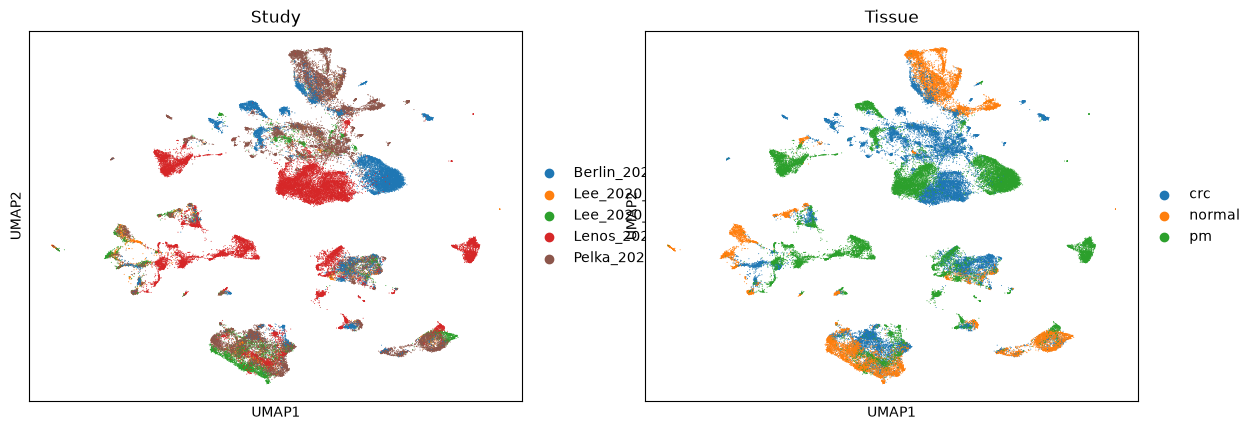

In [40]:
sc.pl.umap(
    adata_train,
    color=[
        "Study",
        "Tissue",
    ],)